In [6]:
import skimage.io as io
import matplotlib.pyplot as plt
import numpy as np
from skimage.color import gray2rgb
from skimage import io, color


# Show the figures / plots inside the notebook
%matplotlib inline
from skimage.color import rgb2gray

def show_images(images,titles=None):
    #This function is used to show image(s) with titles by sending an array of images and an array of associated titles.
    # images[0] will be drawn with the title titles[0] if exists
    # You aren't required to understand this function, use it as-is.
    n_ims = len(images)
    if titles is None: titles = ['(%d)' % i for i in range(1,n_ims + 1)]
    fig = plt.figure()
    n = 1
    for image,title in zip(images,titles):
        a = fig.add_subplot(1,n_ims,n)
        if image.ndim == 2: 
            plt.gray()
        plt.imshow(image)
        a.set_title(title)
        n += 1
    fig.set_size_inches(np.array(fig.get_size_inches()) * n_ims)
    plt.show()


In [1]:

def histogram_equalization(img, G=256):
    H = np.zeros(G)
    N = img.shape[0]
    M = img.shape[1]
    new_img = np.copy(img)

    
    for rowidx, row in enumerate(img):
        for i in range(len(row)):
            img_graylevel = img[rowidx, i]
            if(img_graylevel < G):
                H[img_graylevel] += 1

    H_C = np.zeros(G)
    H_C[0] = H[0]
    for i in range(1, G):
        H_C[i] = H_C[i - 1] + H[i]

    T = np.zeros(G)
    for i in range(G):
        T[i] = round((G - 1) * H_C[i] / (M * N) )

    for rowidx, row in enumerate(img):
        for i in range(len(row)):
            img_graylevel = img[rowidx, i]
            new_img[rowidx, i] = T[img_graylevel]


    return new_img.astype(np.uint8)

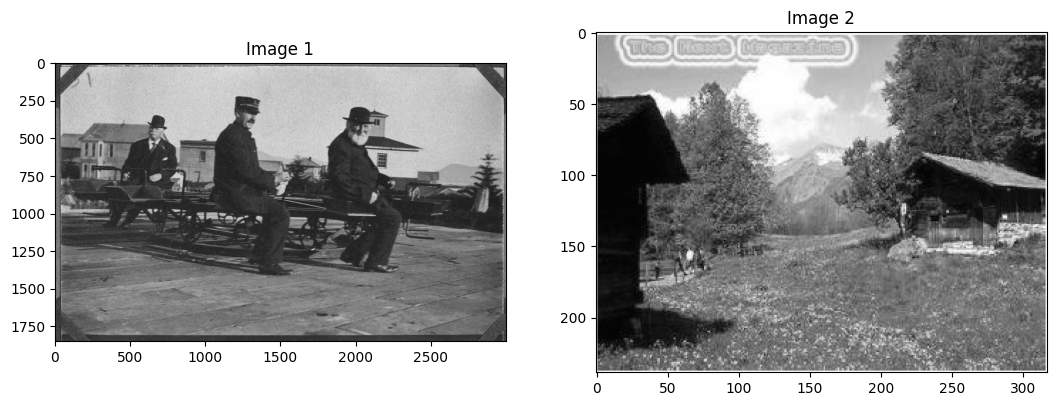

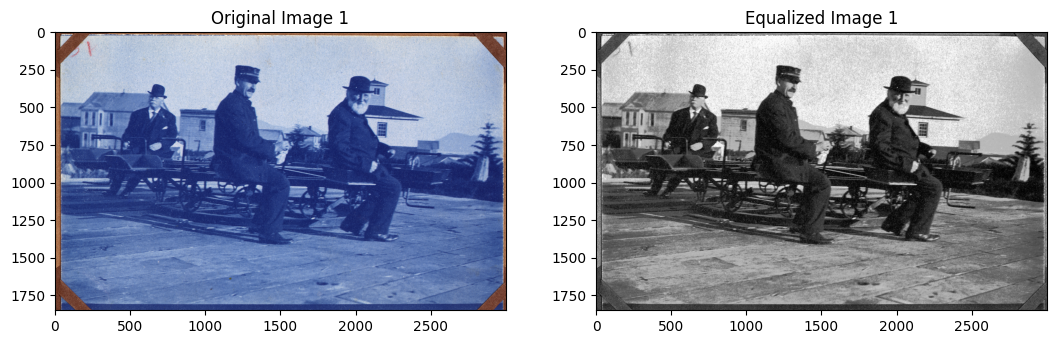

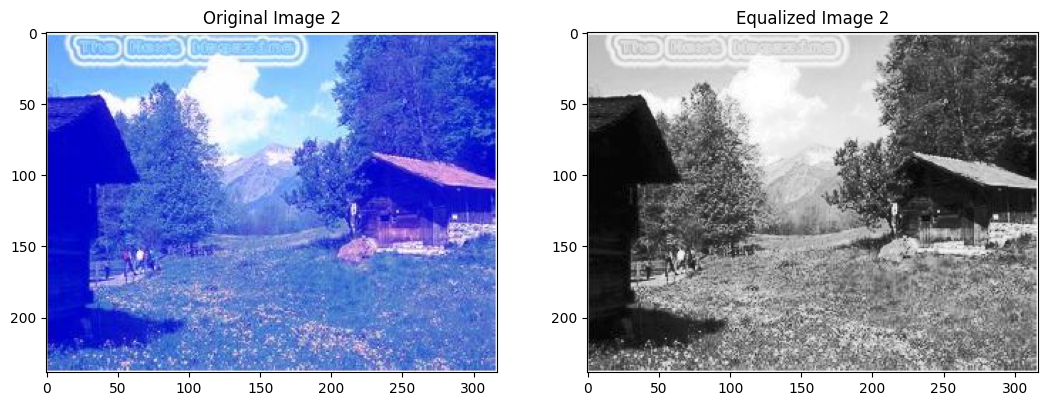

In [8]:

img1 = rgb2gray(io.imread('1.jpg'))
img2 = rgb2gray(io.imread('2.jpg'))

show_images([img1, img2], ['Image 1', 'Image 2'])

new_img1 = histogram_equalization((img1 * 255).astype(np.uint8))
new_img2 = histogram_equalization((img2 * 255).astype(np.uint8))

rgb1 = gray2rgb(new_img1)
rgb2 = gray2rgb(new_img2)

show_images([io.imread('1.jpg'), rgb1], ['Original Image 1', 'Equalized Image 1'])
show_images([io.imread('2.jpg'), rgb2], ['Original Image 2', 'Equalized Image 2'])



In [13]:
def color_correction(img):
    # Split channels
    b = np.copy(img[:,:,0])
    g = np.copy(img[:,:,1])
    r = np.copy(img[:,:,2])
    
    # Option 1: scale each channel to match mean intensity
    mean_r, mean_g, mean_b = np.mean(r), np.mean(g), np.mean(b)
    mean_gray = (mean_r + mean_g + mean_b) / 3
    
    scale_r = mean_gray / mean_r
    scale_g = mean_gray / mean_g
    scale_b = mean_gray / mean_b
    
    r *= scale_r
    g *= scale_g
    b *= scale_b
    
    # Merge back
    corrected = np.stack([b, g, r], axis=2)
    corrected = np.clip(corrected, 0, 255).astype(np.uint8)
    
    return corrected

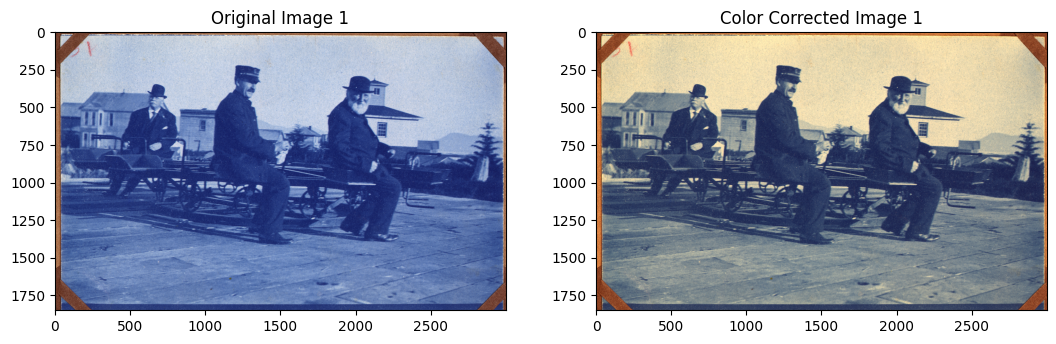

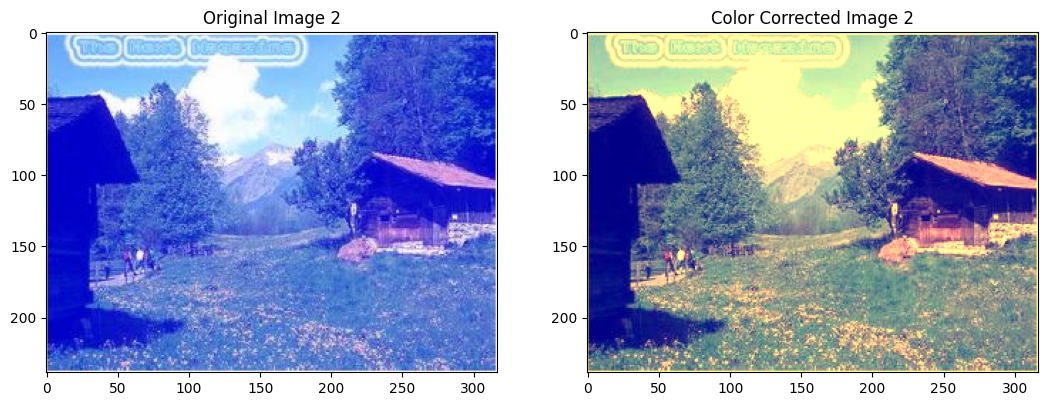

In [15]:
img1 = io.imread('1.jpg')
img2 = io.imread('2.jpg')

corrected1 = color_correction(img1.astype(np.float32))
corrected2 = color_correction(img2.astype(np.float32))



show_images([img1.astype(np.uint8), corrected1], ['Original Image 1', 'Color Corrected Image 1'])
show_images([img2.astype(np.uint8), corrected2], ['Original Image 2', 'Color Corrected Image 2'])
